In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
%cd /content/drive/MyDrive/Colab \Notebooks/microscopy_self_supervised_learning/microscopy_self_supervised_learning

/content/drive/MyDrive/Colab Notebooks/microscopy_self_supervised_learning/microscopy_self_supervised_learning


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [ ]:
# metadata with moa
full_meta = pd.read_csv("data/processed/metadata_with_moa.csv")
full_meta.head(3)

,TableNumber,ImageNumber,Image_FileName_DAPI,Image_PathName_DAPI,Image_FileName_Tubulin,Image_PathName_Tubulin,Image_FileName_Actin,Image_PathName_Actin,plate,well,Replicate,compound,concentration,moa
0,1,11,Week1_150607_B04_s3_w135D66B4C-0548-4AB8-A57B-...,Week1_22123,Week1_150607_B04_s3_w2D81AEFB9-9DD4-4B59-9177-...,Week1_22123,Week1_150607_B04_s3_w408BE006A-BF34-457E-81A9-...,Week1_22123,Week1_22123,B04,1,cytochalasin B,10.0,Actin disruptors
1,1,12,Week1_150607_B04_s4_w1EB720AD1-83BA-48A7-8C47-...,Week1_22123,Week1_150607_B04_s4_w261B79A05-7534-46F3-8C80-...,Week1_22123,Week1_150607_B04_s4_w49FF7E7B1-F049-4994-BCA2-...,Week1_22123,Week1_22123,B04,1,cytochalasin B,10.0,Actin disruptors
2,1,9,Week1_150607_B04_s1_w11323931B-BDA7-4F42-870E-...,Week1_22123,Week1_150607_B04_s1_w2F8F7EA7A-EC57-49CA-A556-...,Week1_22123,Week1_150607_B04_s1_w494DCA5C4-3531-497D-A8B0-...,Week1_22123,Week1_22123,B04,1,cytochalasin B,10.0,Actin disruptors


In [ ]:
full_meta.columns

Index(['TableNumber', 'ImageNumber', 'Image_FileName_DAPI',
       'Image_PathName_DAPI', 'Image_FileName_Tubulin',
       'Image_PathName_Tubulin', 'Image_FileName_Actin',
       'Image_PathName_Actin', 'plate', 'well', 'Replicate', 'compound',
       'concentration', 'moa'],
      dtype='object')

In [ ]:
#Basic sanity check
print("Total rows:", len(full_meta))
print("Unique compounds:", full_meta["compound"].nunique())
print("Unique MOAs:", full_meta["moa"].nunique())
print(full_meta["moa"].value_counts())

Total rows: 3848
Unique compounds: 39
Unique MOAs: 13
moa
Microtubule stabilizers      1428
DMSO                         1320
Microtubule destabilizers     168
Eg5 inhibitors                144
Aurora kinase inhibitors      144
DNA damage                    108
Protein synthesis              96
DNA replication                96
Epithelial                     88
Protein degradation            84
Cholesterol-lowering           72
Actin disruptors               60
Kinase inhibitors              40
Name: count, dtype: int64


In [ ]:
full_meta.duplicated().sum() #any duplicates

np.int64(0)

In [ ]:
import os
os.makedirs("../results/figures", exist_ok=True)

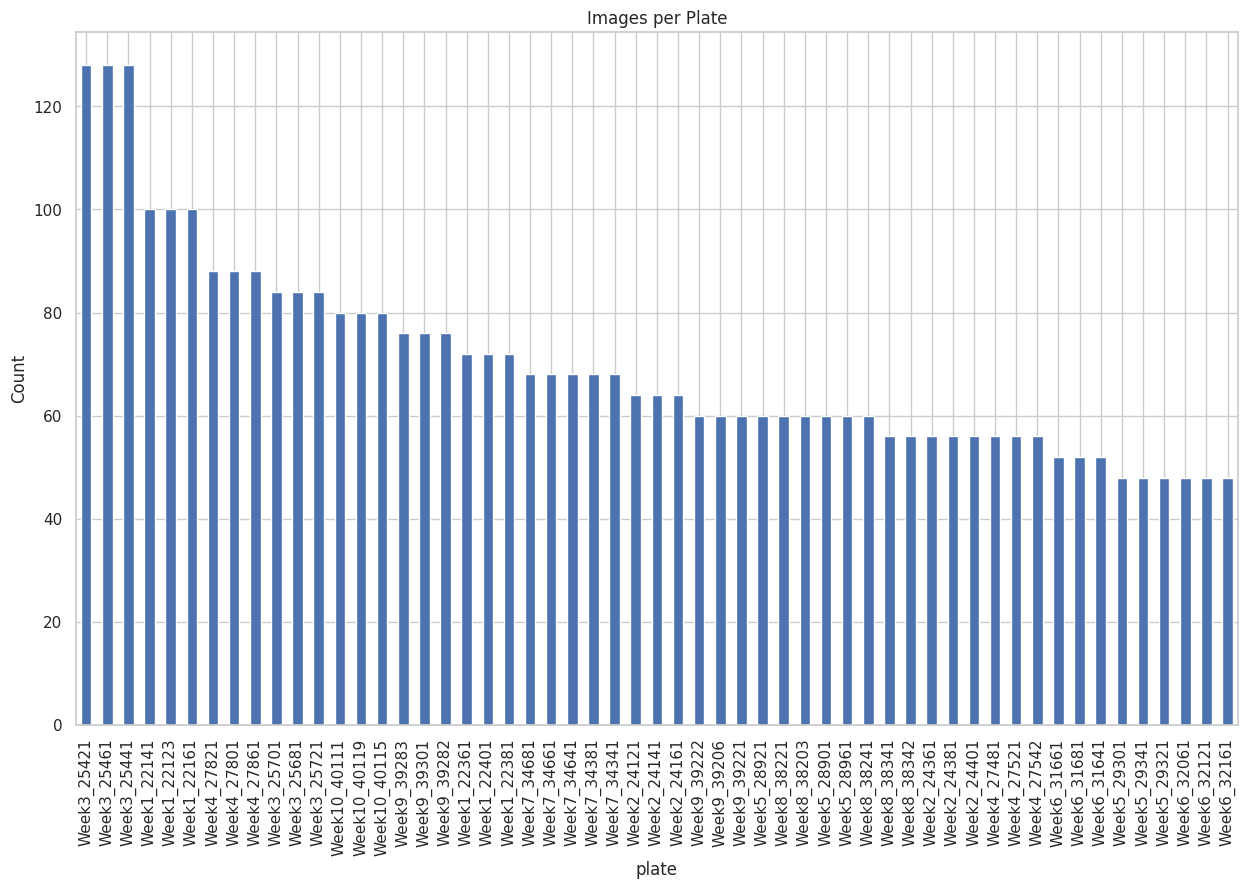

In [ ]:
#Plate and well coverage
plt.figure(figsize=(15,9))
full_meta["plate"].value_counts().plot(kind="bar")
plt.title("Images per Plate")
plt.ylabel("Count")
plt.show()

In [ ]:
#Missing MOa
missing = full_meta[full_meta["moa"].isna()]

print("Images without MOA:", len(missing))
missing["compound"].value_counts().head(10)

Images without MOA: 0


,count
compound,


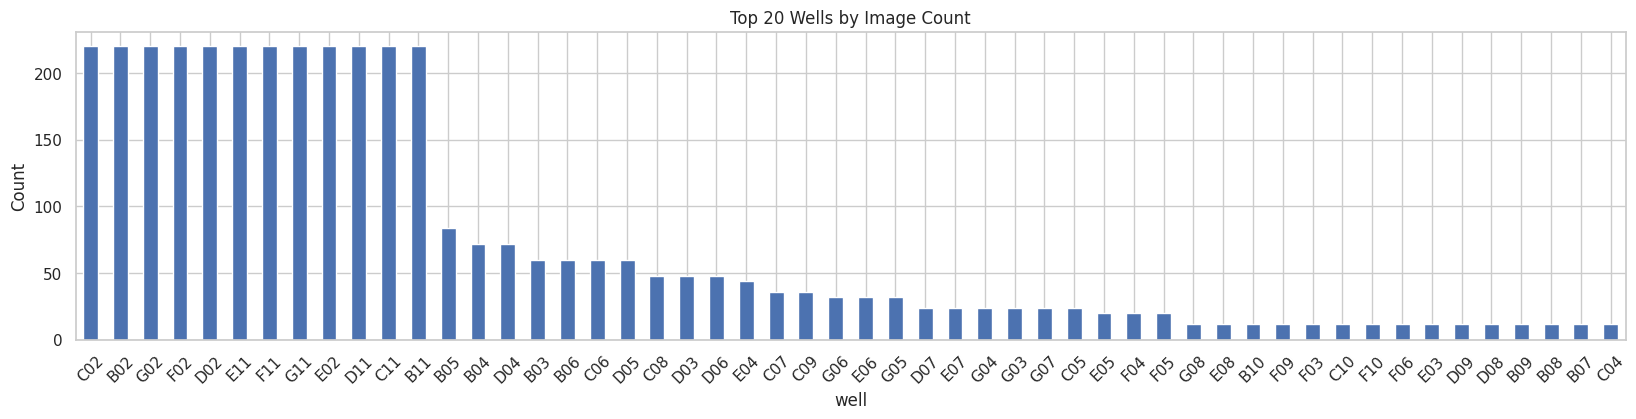

In [38]:
full_meta["well"].value_counts().head(65).plot(kind="bar", figsize=(20,4))
plt.title("Top 20 Wells by Image Count")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

model might memorize specific wells.

overfitting
poor generalization

Step 1: Compound vs MOA mapping

In [ ]:
full_meta[['compound','moa']].drop_duplicates().value_counts() #So that each compund maps to a consistent MOA
# how many compounds per MOA class

,,count
compound,moa,
ALLN,Protein degradation,1
AZ-A,Aurora kinase inhibitors,1
AZ-C,Eg5 inhibitors,1
AZ-J,Epithelial,1
AZ-U,Epithelial,1
AZ138,Eg5 inhibitors,1
AZ258,Aurora kinase inhibitors,1
AZ841,Aurora kinase inhibitors,1
DMSO,DMSO,1


conclusion:
No compound appears with multiple MOAs

Step 2: Plates & batch effects

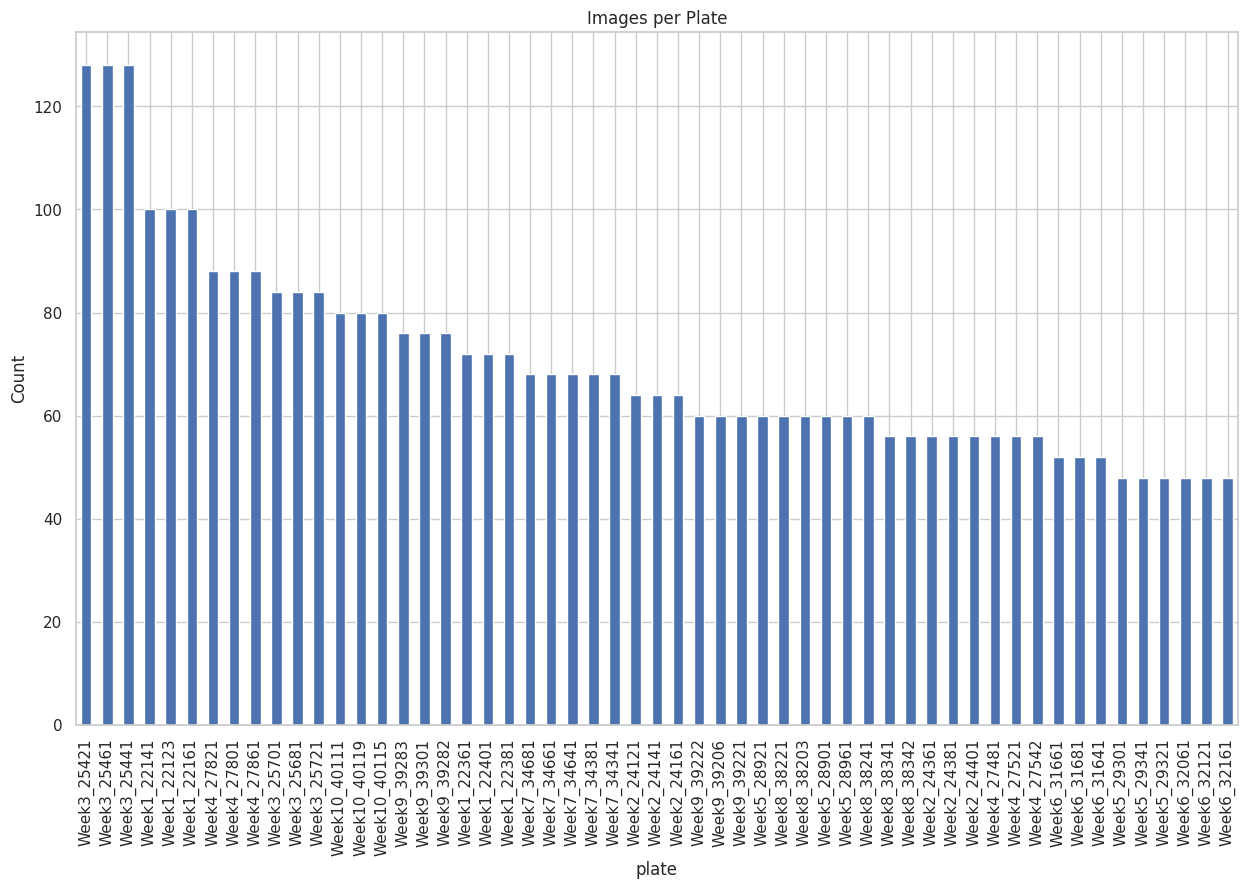

In [ ]:
plt.figure(figsize=(15,9))
full_meta['plate'].value_counts().plot(kind='bar') #UMAP later colored by plate (important for batch bias).
plt.title("Images per Plate")
plt.ylabel("Count")
plt.show()

Step 3: Concentration vs MOA

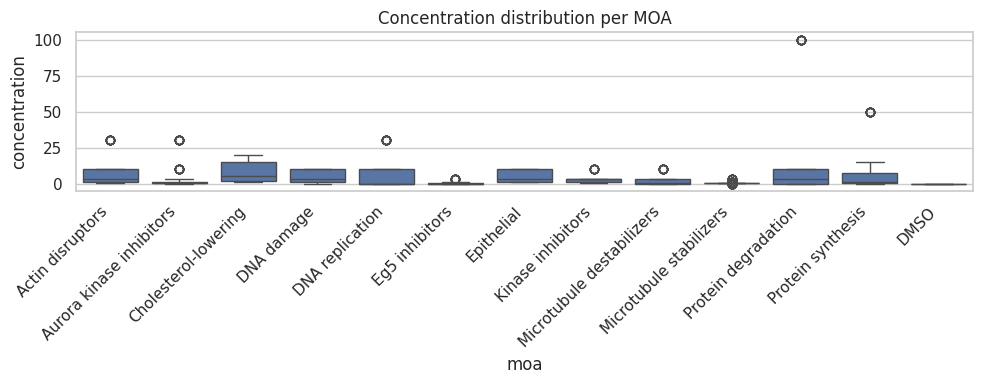

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
sns.boxplot(data=full_meta, x='moa', y='concentration')
plt.xticks(rotation=45, ha='right')
plt.title("Concentration distribution per MOA")
plt.tight_layout()
plt.show()

Cell morphology depends strongly on dose.

If concentrations differ across MOAs:

model may learn concentration effects
instead of biological mechanism

Conclucion : some MOAs only present at high or low doses

Step 4: Replicate counts

In [ ]:
rep_counts =  full_meta.groupby(['compound','concentration']).size()
rep_counts.describe()

,0
count,104.0000
mean,37.0000
std,181.3749
min,8.0000
25%,12.0000
50%,12.0000
75%,12.0000
max,1332.0000


Text(0, 0.5, 'Frequency')

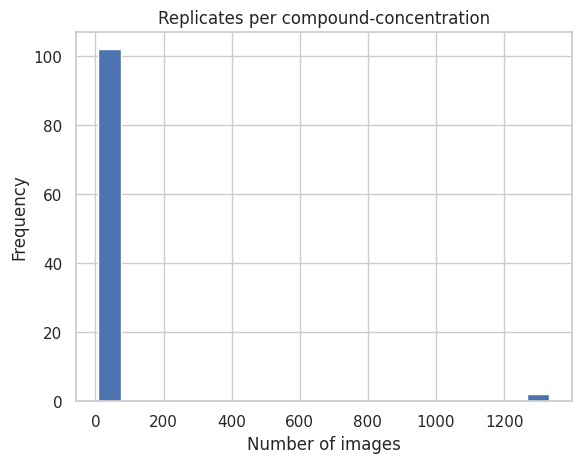

In [ ]:
rep_counts.plot(kind='hist', bins=20, title="Replicates per compound-concentration")
plt.xlabel("Number of images")
plt.ylabel("Frequency")

More replicates =

more stable embeddings
better clustering

More replicates =

more stable embeddings
better clustering

Conclusion:

We have 20 unique (compound, concentration) conditions

Most conditions have 12 replicates



Outlier :“Most compound–concentration conditions have approximately 12 replicate images, reflecting the experimental design. A small number of treatments are overrepresented with more than 70 replicates, likely due to repeated measurements across plates. This imbalance motivates aggregating features per treatment and using compound-level cross-validation in downstream analysis.”

In [ ]:
rep_counts.sort_values(ascending=False).head(20)

compound  concentration
taxol     0.300            1332
DMSO      0.000            1320
AZ-A      0.100              12
ALLN      3.000              12
AZ-A      1.000              12
          3.000              12
          10.000             12
ALLN      100.000            12
AZ-A      30.000             12
AZ-C      0.001              12
          0.010              12
          0.003              12
          0.100              12
          0.300              12
          1.000              12
          0.030              12
AZ-J      3.000              12
          10.000             12
AZ-U      1.000              12
          3.000              12
dtype: int64

Connclusion :

1. Taxol is overrepresented in the dataset.

It is likely used as a positive control.

Appears across multiple plates and replicates.

Researchers want very reliable phenotypes for it.

2. DMSO is the negative control (no drug effect).

DMSO is heavily replicated as a baseline reference condition.

Cells treated with DMSO represent the “normal” phenotype.

It is included in every plate for calibration and QC.

Step 5: Control vs treated

In [ ]:
full_meta['is_control'] = full_meta['compound']=='DMSO'
full_meta['is_control'].value_counts()

,count
is_control,
False,2528
True,1320


DMSO = negative control

used for normalization later

baseline phenotype

72 images are DMSO (control)

228 images are drug-treated

Total = 300 images

Text(0.5, 1.0, 'Control vs treated per plate')

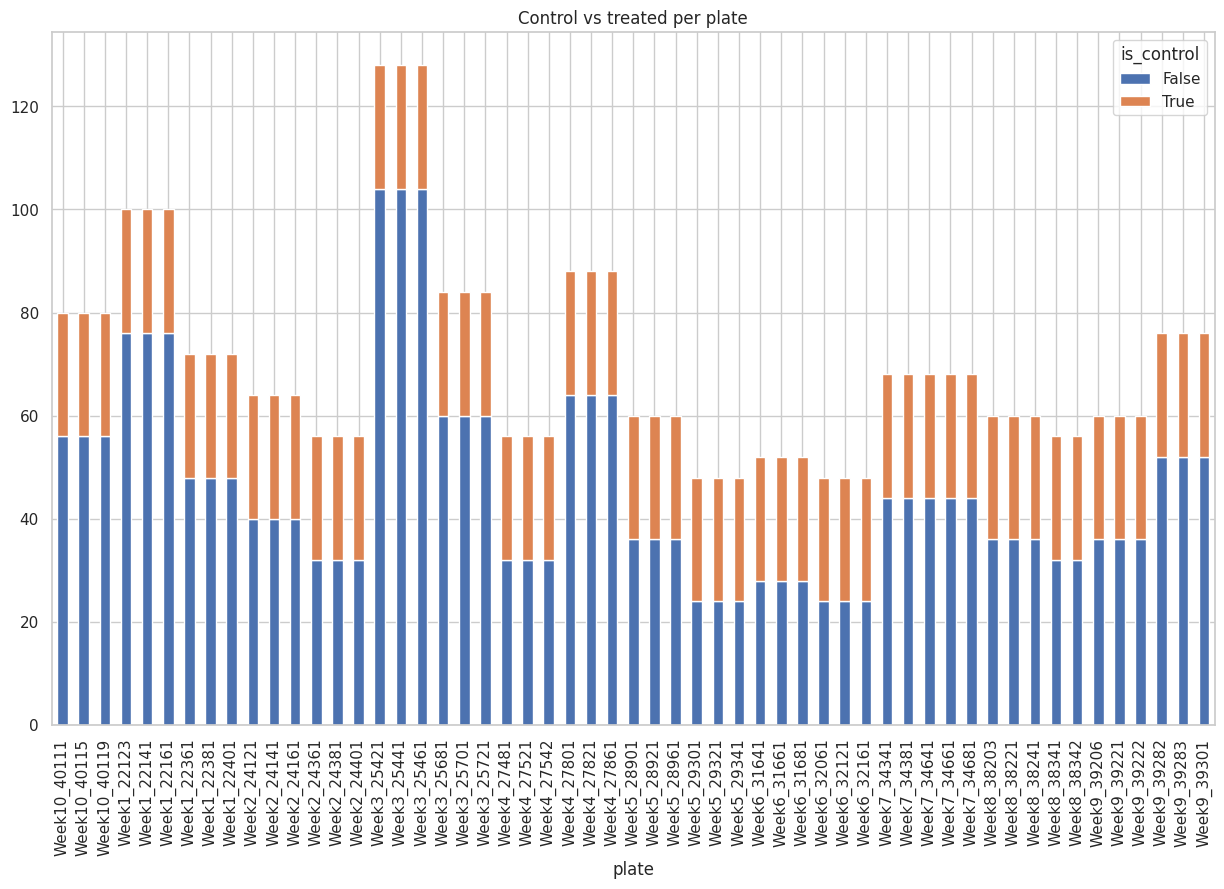

In [31]:
full_meta.groupby(['plate','is_control']).size().unstack().plot(kind='bar', stacked=True, figsize=(15,9))
plt.title("Control vs treated per plate")

Replicate analysis shows that most compound–concentration conditions contain approximately 12 images, reflecting the intended experimental design. Two conditions, Taxol (0.3 µM) and DMSO (0 µM), are strongly overrepresented with 84 and 72 images respectively, consistent with their role as positive and negative controls included across multiple plates. This imbalance motivates treatment-level aggregation and compound-level cross-validation in downstream modeling.

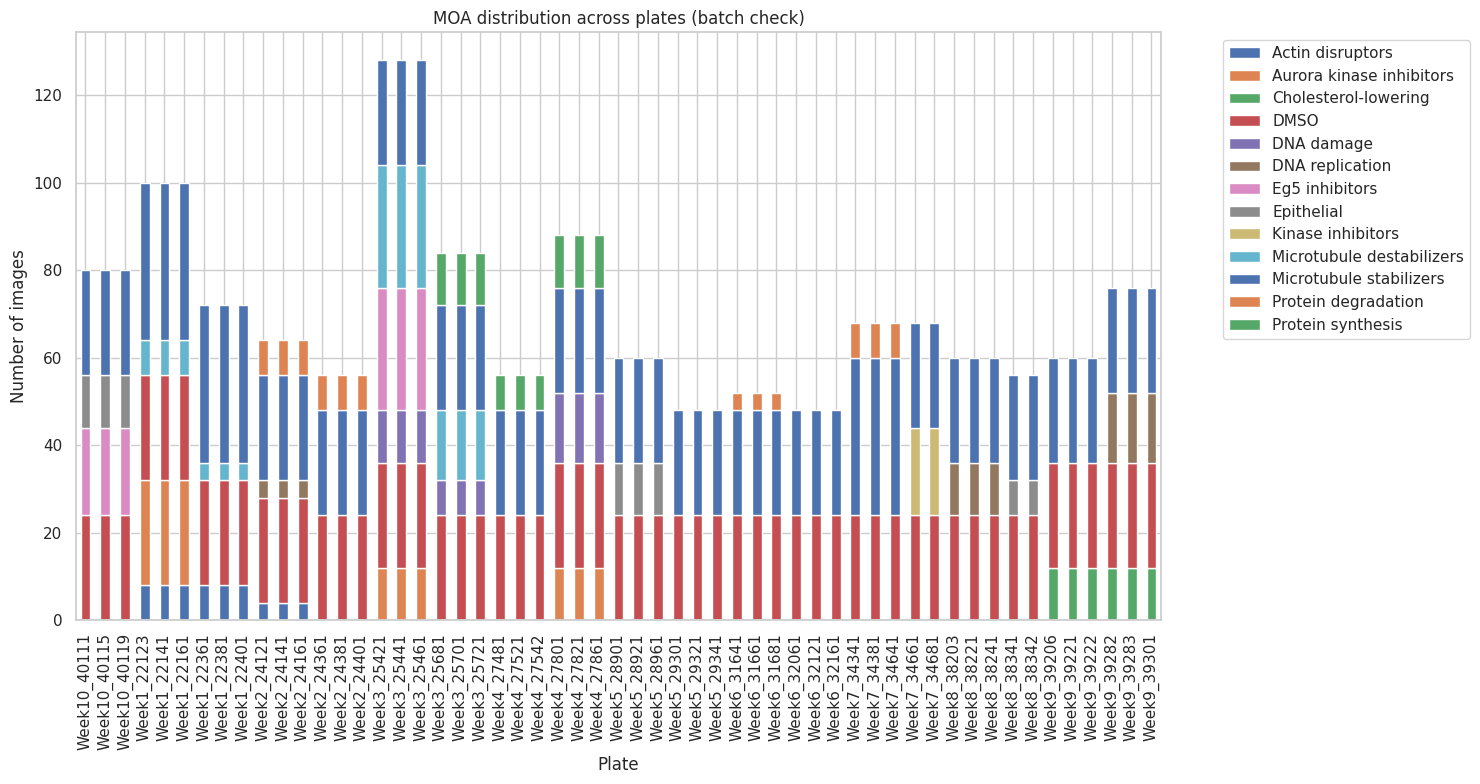

In [34]:
# Plot: MOA vs Plate (batch bias check)
plate_moa = full_meta.groupby(['plate','moa']).size().unstack(fill_value=0)

plate_moa.plot(kind='bar', stacked=True, figsize=(15,8))
plt.title("MOA distribution across plates (batch check)")
plt.xlabel("Plate")
plt.ylabel("Number of images")
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()

Whether certain MOAs appear only on certain plates.

Example:

Plate 1 → MOA A
Plate 2 → MOA B
Plate 3 → MOA C
This is extremely dangerous

Then the model learns:

plate → MOA

instead of

cell morphology → MOA

This is a classic dataset leakage problem in biological ML.

Metadata exploration confirms consistent image resolution, expected replicate structure, control/treatment balance, and moderate class imbalance driven by control conditions (Taxol, DMSO). Plate-level visualization suggests [no/severe] batch–MOA confounding.